# 台北房價預

1. 讀取與檢視房價資料  
2. 觀察目標欄位 `總價` 與重要特徵的關係  
3. 使用 `pd.get_dummies()` 處理類別欄位  
4. 使用 `train_test_split` 切分訓練資料與測試資料  
5. 使用 `StandardScaler` 做標準化  
6. 使用 `LinearRegression` 建立房價預測模型  
7. 使用 `RMSE`、`MAE`、`R^2` 評估預測誤差  
8. 模擬使用者填寫相關欄位的資訊，然後使用 CV 後的模型來預測


| 欄位名稱 | 中文說明 | 原始型態 | 資料角色 | 內容說明 | 缺漏值 | 建模時的處理建議 |
|---|---|---|---|---|---:|---|
| `行政區` | 房屋所在行政區 | `object` | 類別特徵 | 例如文山區、信義區、松山區、大安區 | 0 | 需要進行類別編碼，例如 `pd.get_dummies()` |
| `土地面積` | 土地面積 | `float64` | 數值特徵 | 房屋交易所包含的土地面積，推測單位為平方公尺 | 0 | 可作為房價預測特徵；若使用線性模型，可考慮標準化 |
| `建物總面積` | 建物總面積 | `float64` | 數值特徵 | 建物交易面積，通常是影響房價的重要因素 | 0 | 很重要的預測特徵；若使用線性模型，可考慮標準化 |
| `屋齡` | 房屋年齡 | `float64` | 數值特徵 | 房屋已使用年數，數值越大通常代表屋齡越高 | 0 | 可作為模型特徵；可能與房價呈現負相關 |
| `樓層` | 交易物件所在樓層 | `int64` | 數值 / 序位特徵 | 表示該房屋位於第幾樓 | 0 | 可直接作為模型特徵 |
| `總樓層` | 建物總樓層數 | `int64` | 數值特徵 | 表示整棟建築物共有幾層樓 | 0 | 可直接作為模型特徵 |
| `用途` | 房屋用途編碼 | `int64` | 類別 / 編碼特徵 | 資料中以 `0`、`1` 表示不同用途；原始 CSV 未附明確對照表 | 0 | 可先當成二元類別特徵使用；不建議未查證就解釋 0/1 的實際含義 |
| `房數` | 房間數 | `int64` | 數值特徵 | 房屋格局中的房間數 | 0 | 可直接作為模型特徵 |
| `廳數` | 客廳 / 餐廳數 | `int64` | 數值特徵 | 房屋格局中的廳數 | 0 | 可直接作為模型特徵 |
| `衛數` | 衛浴數 | `int64` | 數值特徵 | 房屋格局中的衛浴數 | 0 | 可直接作為模型特徵 |
| `電梯` | 是否有電梯 | `int64` | 二元類別特徵 | `0`、`1` 編碼；通常可理解為是否有電梯 | 0 | 可直接作為 0/1 特徵使用 |
| `車位類別` | 車位種類 | `object` | 類別特徵 | 例如無、坡道平面、坡道機械、升降機械等 | 0 | 需要進行類別編碼，例如 `pd.get_dummies()` |
| `交易日期` | 不動產交易日期 | `object` | 日期欄位 | 例如 `2019/10/6` | 0 | 入門範例可先不使用；進階可轉成年度、月份等特徵 |
| `經度` | 房屋位置經度 | `float64` | 數值 / 空間特徵 | 表示房屋所在位置的 longitude | 0 | 可作為地理位置特徵使用 |
| `緯度` | 房屋位置緯度 | `float64` | 數值 / 空間特徵 | 表示房屋所在位置的 latitude | 0 | 可作為地理位置特徵使用 |
| `總價` | 房屋交易總價 | `int64` | 目標欄位 | 房屋交易總價，推測單位為萬元 | 0 | 迴歸任務的預測目標 `y` |

In [1]:
# 忽略警告訊息
import warnings
warnings.filterwarnings("ignore")

# 匯入必要的套件
import matplotlib.pyplot as plt

# 設定字型，確保中文能顯示微軟正黑體
plt.rcParams["font.family"] = "Microsoft JhengHei"

# 設定數學字型，確保負號能正常顯示
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["mathtext.fontset"] = "dejavusans"

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import joblib

In [3]:
# 讀取資料
df = pd.read_csv('./Taipei_house.csv')

# 檢視資料
df.head()

,行政區,土地面積,建物總面積,屋齡,樓層,總樓層,用途,房數,廳數,衛數,電梯,車位類別,交易日期,經度,緯度,總價
0,文山區,33.81,109.42,38.996009,3,5,0,3,2,2,0,無,2019/10/6,121.552517,25.004507,1000
1,文山區,32.19,163.53,23.781460,3,11,0,3,2,2,1,坡道平面,2019/4/28,121.559133,24.983199,2100
2,文山區,60.25,204.79,0.744711,1,10,0,3,2,3,1,無,2019/10/23,121.576052,24.988665,6720
3,文山區,16.99,80.31,0.506513,5,10,0,3,2,2,1,坡道平面,2019/7/28,121.576052,24.988665,1110
4,文山區,25.98,86.73,36.099304,4,5,0,3,2,2,0,無,2019/9/28,121.563486,24.995213,800


In [4]:
# 檢視資料的基本資訊
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12429 entries, 0 to 12428
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   行政區     12429 non-null  str    
 1   土地面積    12429 non-null  float64
 2   建物總面積   12429 non-null  float64
 3   屋齡      12429 non-null  float64
 4   樓層      12429 non-null  int64  
 5   總樓層     12429 non-null  int64  
 6   用途      12429 non-null  int64  
 7   房數      12429 non-null  int64  
 8   廳數      12429 non-null  int64  
 9   衛數      12429 non-null  int64  
 10  電梯      12429 non-null  int64  
 11  車位類別    12429 non-null  str    
 12  交易日期    12429 non-null  str    
 13  經度      12429 non-null  float64
 14  緯度      12429 non-null  float64
 15  總價      12429 non-null  int64  
dtypes: float64(5), int64(8), str(3)
memory usage: 1.5 MB


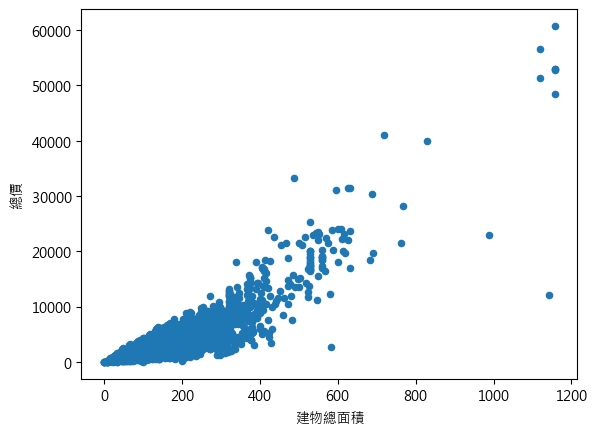

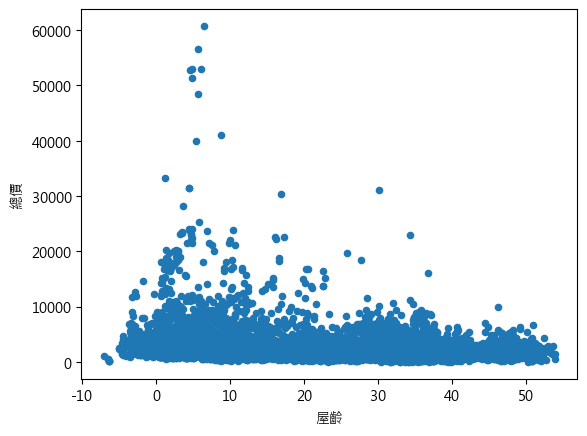

In [5]:
# 觀察總價與重要特徵的關係
df.plot(kind='scatter', x='建物總面積', y='總價')
plt.show()

df.plot(kind='scatter', x='屋齡', y='總價')
plt.show()

In [6]:
# 選擇數值型特徵、類別型特徵與目標變數
X_num = df[['土地面積', '建物總面積', '屋齡', '樓層', '總樓層', '用途', '房數', '廳數', '衛數', '電梯', '經度', '緯度']]
X_cat = pd.get_dummies(df[['行政區', '車位類別']])
y = df['總價']

In [7]:
X_cat.head(5)

,行政區_信義區,行政區_大安區,行政區_文山區,行政區_松山區,車位類別_一樓平面,車位類別_其他,車位類別_升降平面,車位類別_升降機械,車位類別_坡道平面,車位類別_坡道機械,車位類別_塔式車位,車位類別_無
0,False,False,True,False,False,False,False,False,False,False,False,True
1,False,False,True,False,False,False,False,False,True,False,False,False
2,False,False,True,False,False,False,False,False,False,False,False,True
3,False,False,True,False,False,False,False,False,True,False,False,False
4,False,False,True,False,False,False,False,False,False,False,False,True


In [8]:
# 切分訓練資料與測試資料
X_num_train, X_num_test, X_cat_train, X_cat_test, y_train, y_test = train_test_split(
    X_num, X_cat, y, test_size=0.2, random_state=0
)

# 數值型特徵標準化
scaler = StandardScaler()
X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_test_scaled = scaler.transform(X_num_test)

# 合併數值型特徵與類別型特徵
X_train = np.concatenate([X_num_train_scaled, X_cat_train], axis=1)
X_test = np.concatenate([X_num_test_scaled, X_cat_test], axis=1)

In [9]:
display(pd.DataFrame(X_train, columns=list(X_num.columns) + list(X_cat.columns)))
display(pd.DataFrame(X_test, columns=list(X_num.columns) + list(X_cat.columns)))

,土地面積,建物總面積,屋齡,樓層,總樓層,用途,房數,廳數,衛數,電梯,...,行政區_文山區,行政區_松山區,車位類別_一樓平面,車位類別_其他,車位類別_升降平面,車位類別_升降機械,車位類別_坡道平面,車位類別_坡道機械,車位類別_塔式車位,車位類別_無
0,-0.591586,0.038573,0.542777,1.320198,1.039551,-0.346534,-0.563119,0.534204,0.455047,0.490458,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.964715,-0.464656,0.376537,1.320198,0.282358,-0.346534,-0.563119,0.534204,-0.892743,0.490458,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.970060,-1.096125,-0.738226,0.536965,0.093059,2.885722,-1.467658,-1.280483,-0.892743,0.490458,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.599706,0.029326,0.991816,-1.029502,-1.042730,-0.346534,1.245958,0.534204,0.455047,-2.038911,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.050355,-0.385205,0.904684,-0.246268,-1.042730,-0.346534,0.341420,0.534204,0.455047,-2.038911,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9938,-1.072573,-0.981147,0.437110,-0.507346,1.607446,2.885722,-1.467658,-1.280483,-0.892743,0.490458,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9939,1.154055,0.644856,0.057433,0.275887,0.093059,-0.346534,1.245958,0.534204,-0.892743,0.490458,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9940,-0.884065,-0.554205,-0.753321,-0.507346,0.093059,2.885722,0.341420,-1.280483,-0.892743,0.490458,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
9941,1.024334,0.742193,0.295137,0.014809,-0.474835,-0.346534,0.341420,0.534204,0.455047,0.490458,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


,土地面積,建物總面積,屋齡,樓層,總樓層,用途,房數,廳數,衛數,電梯,...,行政區_文山區,行政區_松山區,車位類別_一樓平面,車位類別_其他,車位類別_升降平面,車位類別_升降機械,車位類別_坡道平面,車位類別_坡道機械,車位類別_塔式車位,車位類別_無
0,0.041955,-0.618204,1.568306,-0.507346,-1.042730,-0.346534,0.341420,0.534204,-0.892743,-2.038911,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.208114,-0.002552,-0.394472,0.014809,0.471656,-0.346534,-0.563119,0.534204,0.455047,0.490458,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-0.772321,-1.176915,0.079598,-0.246268,-0.474835,-0.346534,-1.467658,-1.280483,-0.892743,0.490458,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.732827,-0.079934,0.393161,-0.507346,-1.042730,-0.346534,0.341420,0.534204,0.455047,-2.038911,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.291820,-0.015449,0.894174,-0.246268,0.282358,-0.346534,0.341420,0.534204,-0.892743,0.490458,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2481,-0.060072,-0.462344,1.105700,-0.246268,-1.042730,-0.346534,0.341420,0.534204,-0.892743,-2.038911,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2482,-0.081449,-0.091493,-0.386065,1.059120,0.471656,-0.346534,-0.563119,0.534204,-0.892743,0.490458,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2483,-0.948197,-1.078483,-0.770900,-0.507346,0.093059,2.885722,-1.467658,-1.280483,-0.892743,0.490458,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2484,-0.970546,-1.114376,0.142082,0.014809,0.282358,-0.346534,-1.467658,-1.280483,-0.892743,0.490458,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [10]:
# 建立 LinearRegression 模型
lr = LinearRegression()

# 訓練模型
lr.fit(X_train, y_train)

# 使用 CV 後的模型進行預測
y_pred = lr.predict(X_test)

# 計算 RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# 計算 MAE
mae = mean_absolute_error(y_test, y_pred)

# 計算 R^2
r2 = r2_score(y_test, y_pred)

print('RMSE:', rmse)
print('MAE:', mae)
print('R^2:', r2)
print('前 10 筆預測結果:', y_pred[:10])

RMSE: 1056.114566033352
MAE: 634.8952490122604
R^2: 0.810244715282826
前 10 筆預測結果: [ 783.7302401  2248.51635371 -541.27144312 1397.39592252 2559.73288058
 2672.23057321  141.02312593 1194.4483475  3289.01825724 2223.1846206 ]


In [ ]:
# 儲存模型
joblib.dump(lr, './my_model.joblib')

# 儲存標準化器
joblib.dump(scaler, './my_scaler.joblib')

# 載入模型
lr_loaded = joblib.load('./my_model.joblib')

# 載入標準化器
scaler_loaded = joblib.load('./my_scaler.joblib')

In [12]:
# 模擬使用者填寫一筆房屋資料
# 數值欄位順序要跟 X_num 完全一樣
user_num = [[
    33.81,       # 土地面積
    109.42,      # 建物總面積
    38.996,      # 屋齡
    3,           # 樓層
    5,           # 總樓層
    0,           # 用途
    3,           # 房數
    2,           # 廳數
    2,           # 衛數
    0,           # 電梯
    121.552517,  # 經度
    25.004507    # 緯度
]]

user_district = '文山區'
user_parking = '無'

# 數值型特徵標準化
user_num_scaled = scaler_loaded.transform(user_num)

# 類別型特徵轉成跟 X_cat 一樣的 dummy 欄位
user_cat = []
for col in X_cat.columns:
    if col == '行政區_' + user_district or col == '車位類別_' + user_parking:
        user_cat.append(1)
    else:
        user_cat.append(0)
user_cat = [user_cat]

# 合併數值型特徵與類別型特徵
user_X = np.concatenate([user_num_scaled, user_cat], axis=1)

# 使用 CV 後的模型預測
pred_price = lr_loaded.predict(user_X)

print('預測總價:', pred_price[0])

預測總價: 1384.7780293567632


延伸議題：
- 是不是所有特徵都對房價有影響？如何判斷特徵的重要性？
- 如果要提升模型的效能，還有哪些方法可以嘗試？例如特徵工程、模型選擇、超參數調整等。
- 如果要將房價預測模型部署到線上系統，該怎麼做？

你可以用 AI 來協助你完成這些延伸議題的研究與實作，並且可以透過 AI 來幫助你分析特徵的重要性、選擇合適的模型、調整超參數，甚至將模型部署到線上系統。